Processing 2D to 3D Image Shift...
Original Image Preview:


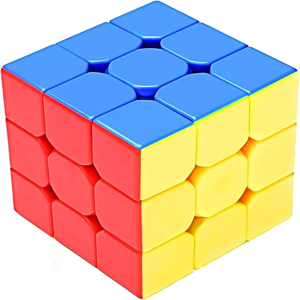


Generated 3D-Shifted Result View:


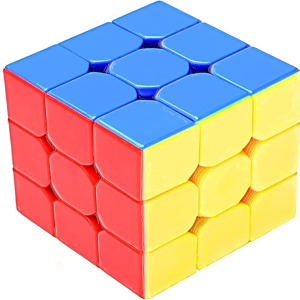

In [1]:
import numpy as np
import cv2
from PIL import Image

def shift_image(img, depth_img, shift_amount=10):

    img = img.convert("RGBA")
    data = np.array(img)

    depth_img = depth_img.convert("L")
    depth_data = np.array(depth_img)

    deltas = ((depth_data / 255.0) * float(shift_amount)).astype(int)

    shifted_data = np.zeros_like(data)
    height, width, _ = data.shape


    for y, row in enumerate(deltas):
        for x, dx in enumerate(row):
            if 0 <= x + dx < width:
                shifted_data[y, x + dx] = data[y, x]

    shifted_image = Image.fromarray(shifted_data.astype(np.uint8))
    return shifted_image


import os

if os.path.exists('sample_data/cv_2.jpg'):
    base_path = 'sample_data/cv_2.jpg'
    depth_path = 'sample_data/cv_2_depth.jpg'

elif os.path.exists('cv_2.jpg'):
    base_path = 'cv_2.jpg'
    depth_path = 'cv_2_depth.jpg'
else:
    print("Error: Could not find 'cv_2.jpg'. Please upload it to your Colab files panel panel.")
    base_path = None

if base_path:

    temp_img = cv2.imread(base_path)
    if temp_img is not None:

        gray = cv2.cvtColor(temp_img, cv2.COLOR_BGR2GRAY)
        depth_mock = cv2.GaussianBlur(gray, (21, 21), 0)
        cv2.imwrite(depth_path, depth_mock)


        img = Image.open(base_path)
        depth_img = Image.open(depth_path)

        print("Processing 2D to 3D Image Shift...")

        shifted_result = shift_image(img, depth_img, shift_amount=12)

        print("Original Image Preview:")
        display(img.resize((300, 300)))
        print("\nGenerated 3D-Shifted Result View:")
        display(shifted_result.resize((300, 300)))